In [1]:
#importing packages
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [31]:
file_path = 'Huspris kvartal.xlsx'
df = pd.read_excel(file_path)

df['Year'] = df['Period'].str.extract('(\d{4})')
df['Quarter'] = df['Period'].str.extract('q(\d)')

# Convert to datetime and set as index
df['Period'] = pd.to_datetime(df['Year'] + df['Quarter'], format='%Y%m')
df.set_index('Period', inplace=True)

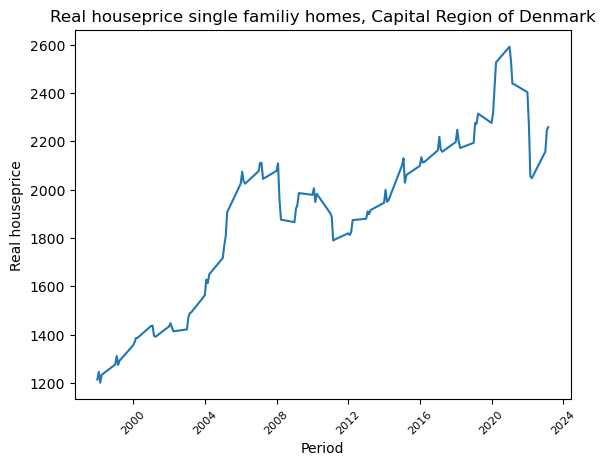

In [37]:
# Plotting the values of the column RHP_EFHL
price = df['RHP_EFHL']
plt.plot(df.index, price)
plt.title('Real houseprice single familiy homes, Capital Region of Denmark') 
plt.xlabel('Period')
plt.ylabel('Real houseprice')
plt.xticks(rotation=45)
plt.show()

DatetimeIndex(['2004-02-01', '2004-03-01', '2004-04-01', '2005-01-01',
               '2005-02-01', '2005-03-01', '2005-04-01', '2006-01-01',
               '2006-02-01', '2006-03-01', '2006-04-01', '2014-03-01',
               '2020-04-01', '2021-01-01', '2021-02-01', '2022-03-01',
               '2022-04-01'],
              dtype='datetime64[ns]', name='Period', freq=None)


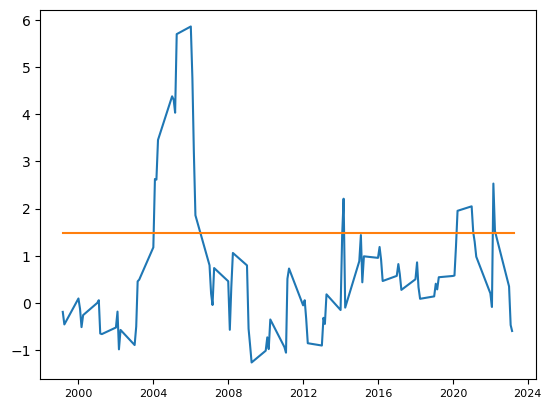

In [38]:
#this is a bubble detecting algorithm developed by Phillips and Yu (2011) and Phillips et al. (2015) 
#it is based on the augmented Dickey-Fuller test and is used to detect bubbles in financial data.

# Generate price variable
prices = df['RHP_EFRH']

# Inputting the parameters
r0 = int(len(prices) * 0.05)
adf_lags = 1
crit = 1.49
#transforming data
log_prices = np.array(np.log(prices))
delta_log_prices = log_prices[1:] - log_prices[:-1]
n = len(delta_log_prices)
BSADF = np.array([])
#calculating ADF stats
for r2 in range(r0,n):
    ADFS = np.array([])
    for r1 in range(0,r2-r0+1):
        X0 = log_prices[r1:r2+1]
        X = pd.DataFrame()
        X[0] = X0
        for j in range(1,adf_lags+1):
            X[j] = np.append(np.zeros(j),delta_log_prices[r1:r2+1-j])
        X = np.array(X)
        Y = delta_log_prices[r1:r2+1]
        reg = sm.OLS(Y,sm.add_constant(X))
        res = reg.fit()
        ADFS = np.append(ADFS, res.params[1]/res.bse[1])
    BSADF = np.append(BSADF, max(ADFS))
#visualising the results
plt.rc('xtick',labelsize = 8)
plt.plot(prices.index[r0+1:],BSADF)
plt.plot(prices.index[r0+1:],np.ones(len(BSADF))*crit)
#printing dates when bubbles were detected
print(prices.index[r0+1:][BSADF > crit])